<a href="https://colab.research.google.com/github/idamidapida/Tugas-Kelompok-ADS/blob/main/Tugas%202%20ADS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =============================================================================
# 1. IMPORT LIBRARY
# =============================================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform

from scipy.optimize import minimize

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from pykrige.ok import OrdinaryKriging

from pykrige.kriging_tools import write_asc_grid

import plotly.graph_objects as go

from plotly.subplots import make_subplots

import warnings

warnings.filterwarnings("ignore")


plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [3]:
# =============================================================================
# 2. DATA SPASIAL DENGAN STRUKTUR AUTOKORELASI
# =============================================================================


print("="*80)
print("TAHAP 1: DATA SPASIAL PENELITIAN")
print("="*80)

# membaca data
data = pd.read_excel(
    "soil.xlsx"
)

print("\nInformasi Data")
print(data.info())

print("\n5 data awal")
print(data.head())

# koordinat spasial

coordinate_x = data["x"].values

coordinate_y = data["y"].values

observed_value = data["zinc"].values


print("\nStatistik Data Zinc")
print(
    pd.Series(observed_value).describe()
)

TAHAP 1: DATA SPASIAL PENELITIAN

Informasi Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       155 non-null    int64
 1   y       155 non-null    int64
 2   zinc    155 non-null    int64
dtypes: int64(3)
memory usage: 3.8 KB
None

5 data awal
        x       y  zinc
0  181072  333611  1022
1  181025  333558  1141
2  181165  333537   640
3  181298  333484   257
4  181307  333330   269

Statistik Data Zinc
count     155.000000
mean      469.716129
std       367.073788
min       113.000000
25%       198.000000
50%       326.000000
75%       674.500000
max      1839.000000
dtype: float64


In [4]:
# =============================================================================
# 3. SAMPLING DATA (DATA OBSERVASI)
# =============================================================================


print("="*80)
print("TAHAP 2: SAMPLING DATA")
print("="*80)


sample_data = data.sample(
    frac=0.8,
    random_state=10
)


validation_data = data.drop(
    sample_data.index
)


print(
    "Jumlah data training:",
    len(sample_data)
)


print(
    "Jumlah data validasi:",
    len(validation_data)
)


TAHAP 2: SAMPLING DATA
Jumlah data training: 124
Jumlah data validasi: 31


In [5]:
# =============================================================================
# 4. ANALISIS VARIOGRAM
# =============================================================================

print("="*80)
print("TAHAP 3: ANALISIS VARIOGRAM")
print("="*80)


# Membuat koordinat spasial
coords = np.column_stack(
    (
        sample_data["x"],
        sample_data["y"]
    )
)


# Nilai observasi zinc
values = sample_data["zinc"].values


print("Jumlah titik observasi:")
print(len(values))

distance_matrix = squareform(
    pdist(coords)
)


variogram_data = []


for i in range(len(values)):

    for j in range(i+1, len(values)):

        distance = distance_matrix[i,j]

        semivariance = (
            (values[i]-values[j])**2
        ) / 2


        variogram_data.append(
            [
                distance,
                semivariance
            ]
        )


variogram_df = pd.DataFrame(
    variogram_data,
    columns=[
        "distance",
        "semivariance"
    ]
)


print(variogram_df.head())

TAHAP 3: ANALISIS VARIOGRAM
Jumlah titik observasi:
124
      distance  semivariance
0  2951.312251     1099644.5
1  1122.748859      808992.0
2   739.649241     1205904.5
3  1866.590475      273060.5
4  1372.433241     1086338.0


TAHAP 4: FITTING MODEL VARIOGRAM TEORITIS


Parameter model exponential:
Nugget : 0.1362566233668397
Sill : 147909.93205232505
Range : 198.0350338326093


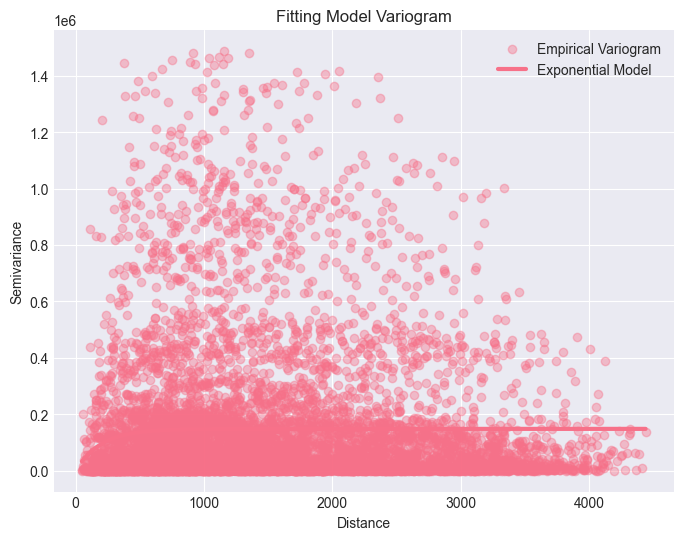

In [6]:
# =============================================================================
# 5. FITTING MODEL VARIOGRAM TEORITIS
# =============================================================================

print("="*80)
print("TAHAP 4: FITTING MODEL VARIOGRAM TEORITIS")
print("="*80)


# Memisahkan data jarak dan semivariance

distance = variogram_df["distance"].values

gamma = variogram_df["semivariance"].values



# Fungsi model variogram

def exponential_model(h, nugget, sill, range_param):

    return nugget + sill * (
        1 - np.exp(-h / range_param)
    )



def spherical_model(h, nugget, sill, range_param):

    result = np.zeros_like(h)

    for i, value in enumerate(h):

        if value <= range_param:

            result[i] = (
                nugget +
                sill *
                (
                    1.5*(value/range_param)
                    -
                    0.5*(value/range_param)**3
                )
            )

        else:

            result[i] = nugget + sill


    return result



def gaussian_model(h, nugget, sill, range_param):

    return nugget + sill * (
        1 - np.exp(
            -(h**2)/(range_param**2)
        )
    )



# Estimasi parameter awal

initial_parameter = [
    0.1,
    np.var(values),
    np.max(distance)/3
]



# fitting exponential

param_exp, _ = minimize(
    lambda p:
    np.sum(
        (
            gamma -
            exponential_model(
                distance,
                p[0],
                p[1],
                p[2]
            )
        )**2
    ),
    initial_parameter,
    method="Nelder-Mead"
).x, None



print("Parameter model exponential:")
print(
    "Nugget :", param_exp[0]
)

print(
    "Sill :", param_exp[1]
)

print(
    "Range :", param_exp[2]
)



# Visualisasi fitting

plt.figure(figsize=(8,6))


plt.scatter(
    distance,
    gamma,
    alpha=0.4,
    label="Empirical Variogram"
)


plt.plot(
    np.sort(distance),
    exponential_model(
        np.sort(distance),
        *param_exp
    ),
    linewidth=3,
    label="Exponential Model"
)



plt.xlabel("Distance")

plt.ylabel("Semivariance")

plt.title(
    "Fitting Model Variogram"
)

plt.legend()

plt.show()

In [7]:
# =============================================================================
# 6. ORDINARY KRIGING PREDICTION
# =============================================================================

print("="*80)
print("TAHAP 5: ORDINARY KRIGING PREDICTION")
print("="*80)



# Membuat grid prediksi

grid_x = np.linspace(
    data["x"].min(),
    data["x"].max(),
    100
)


grid_y = np.linspace(
    data["y"].min(),
    data["y"].max(),
    100
)



# Model Ordinary Kriging

OK = OrdinaryKriging(

    sample_data["x"],

    sample_data["y"],

    sample_data["zinc"],

    variogram_model="exponential",

    verbose=False,

    enable_plotting=False

)



# Prediksi

z_pred, variance = OK.execute(

    "grid",

    grid_x,

    grid_y

)



print("Prediksi kriging selesai")

print(
    "Ukuran grid:",
    z_pred.shape
)



TAHAP 5: ORDINARY KRIGING PREDICTION
Prediksi kriging selesai
Ukuran grid: (100, 100)


TAHAP 6: VISUALISASI HASIL PREDIKSI


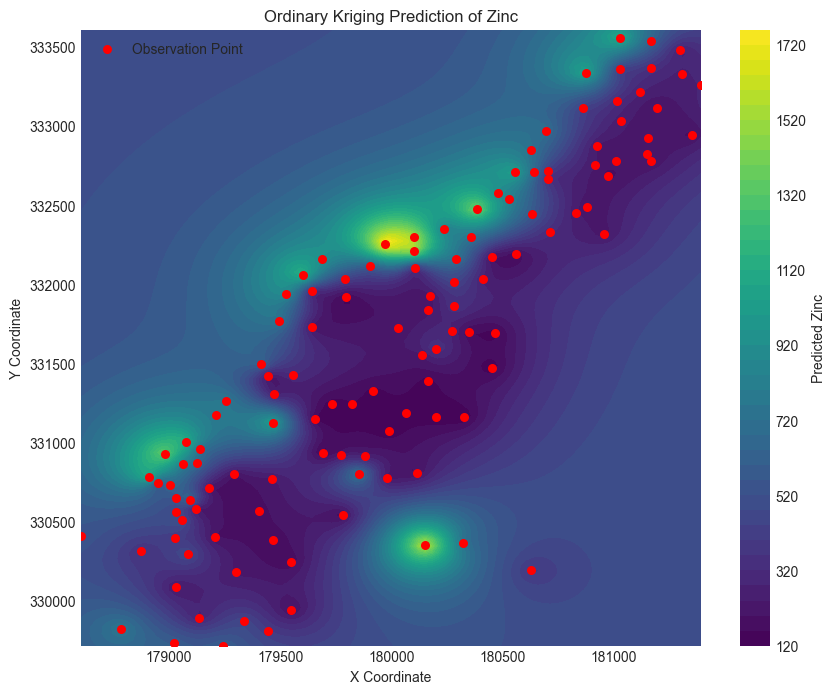

In [8]:
# =============================================================================
# 7. VISUALISASI HASIL KRIGING
# =============================================================================

print("="*80)
print("TAHAP 6: VISUALISASI HASIL PREDIKSI")
print("="*80)



plt.figure(figsize=(10,8))


contour = plt.contourf(

    grid_x,

    grid_y,

    z_pred,

    levels=50,

    cmap="viridis"

)



plt.scatter(

    sample_data["x"],

    sample_data["y"],

    c="red",

    s=30,

    label="Observation Point"

)



plt.colorbar(
    contour,
    label="Predicted Zinc"
)


plt.xlabel("X Coordinate")

plt.ylabel("Y Coordinate")


plt.title(
    "Ordinary Kriging Prediction of Zinc"
)


plt.legend()

plt.show()

In [9]:
# =============================================================================
# 8. VALIDASI DAN EVALUASI PERFORMANCE
# =============================================================================

print("="*80)
print("TAHAP 7: VALIDASI DAN EVALUASI")
print("="*80)



# Kriging pada titik validasi

validation_prediction, validation_variance = OK.execute(

    "points",

    validation_data["x"].to_numpy(dtype=float),

    validation_data["y"].to_numpy(dtype=float)

)



actual = validation_data["zinc"]



RMSE = np.sqrt(
    mean_squared_error(
        actual,
        validation_prediction
    )
)


MAE = mean_absolute_error(

    actual,

    validation_prediction

)


R2 = r2_score(

    actual,

    validation_prediction

)



print("Performance Model Kriging")

print("-----------------------------")

print(
    "RMSE :",
    RMSE
)


print(
    "MAE :",
    MAE
)


print(
    "R2 :",
    R2
)

TAHAP 7: VALIDASI DAN EVALUASI
Performance Model Kriging
-----------------------------
RMSE : 181.58395360307688
MAE : 133.62824238878878
R2 : 0.6894320266431587


TAHAP 8: ANALISIS KETIDAKPASTIAN


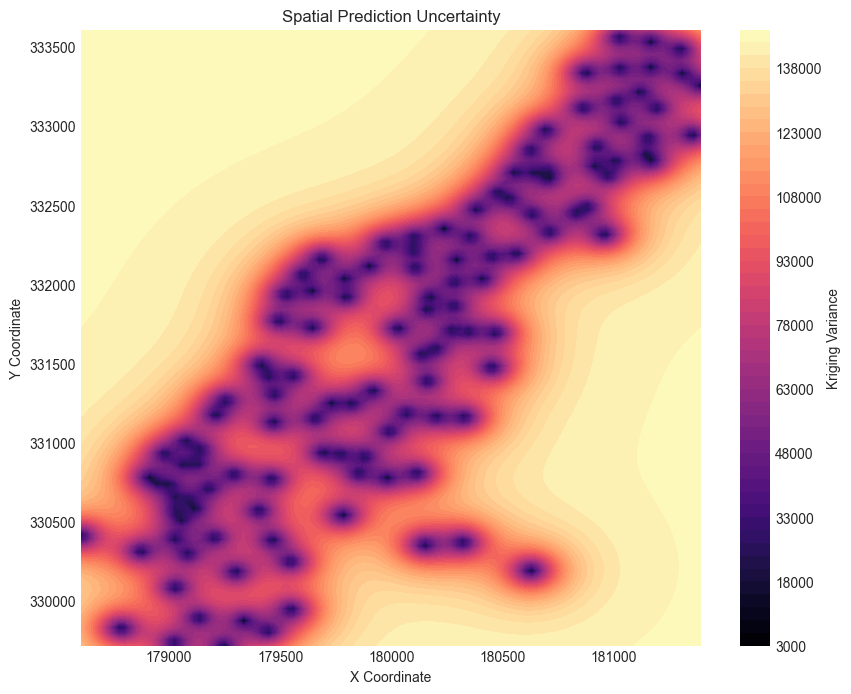

Rata-rata uncertainty: 108656.27071388059
Nilai uncertainty maksimum: 144513.48221323284


In [10]:
# =============================================================================
# 9. ANALISIS KETIDAKPASTIAN
# =============================================================================

print("="*80)
print("TAHAP 8: ANALISIS KETIDAKPASTIAN")
print("="*80)



plt.figure(figsize=(10,8))


uncertainty_plot = plt.contourf(

    grid_x,

    grid_y,

    variance,

    levels=50,

    cmap="magma"

)



plt.colorbar(

    uncertainty_plot,

    label="Kriging Variance"

)



plt.xlabel(
    "X Coordinate"
)


plt.ylabel(
    "Y Coordinate"
)



plt.title(
    "Spatial Prediction Uncertainty"
)



plt.show()



print(
    "Rata-rata uncertainty:",
    np.mean(variance)
)


print(
    "Nilai uncertainty maksimum:",
    np.max(variance)
)

In [11]:
# =============================================================================
# 10. SUMMARY DAN KESIMPULAN
# =============================================================================

print("="*80)
print("SUMMARY DAN KESIMPULAN")
print("="*80)



print(
    f"""
Analisis spasial menggunakan metode Ordinary Kriging
telah dilakukan pada variabel Zinc.


Jumlah data observasi :
{len(data)}


Variabel yang dianalisis :
Zinc


Model variogram :
Exponential


Hasil evaluasi model:

RMSE :
{RMSE:.3f}


MAE :
{MAE:.3f}


R2 :
{R2:.3f}


Kesimpulan:

Model Ordinary Kriging berhasil menghasilkan
estimasi distribusi spasial Zinc berdasarkan
hubungan spasial antar titik observasi.

Peta prediksi menunjukkan variasi nilai Zinc,
sedangkan peta uncertainty menunjukkan tingkat
ketidakpastian hasil interpolasi.
"""
)

SUMMARY DAN KESIMPULAN

Analisis spasial menggunakan metode Ordinary Kriging
telah dilakukan pada variabel Zinc.


Jumlah data observasi :
155


Variabel yang dianalisis :
Zinc


Model variogram :
Exponential


Hasil evaluasi model:

RMSE :
181.584


MAE :
133.628


R2 :
0.689


Kesimpulan:

Model Ordinary Kriging berhasil menghasilkan
estimasi distribusi spasial Zinc berdasarkan
hubungan spasial antar titik observasi.

Peta prediksi menunjukkan variasi nilai Zinc,
sedangkan peta uncertainty menunjukkan tingkat
ketidakpastian hasil interpolasi.

